In [4]:
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import pybedtools
import os
from biodatatools.utils.common import json_dump
import subprocess
import biodataplot.genomeview as gv
import biodataplot.utils as bpu
import glob
from pathlib import Path
import itertools
import numpy as np

In [5]:
matplotlib.font_manager.fontManager.addfont(f"{Path.cwd().parent}/font/Arial.ttf")
matplotlib.rcParams["font.family"] = "Arial"
bfontsize = 12
sfontsize = 9

In [6]:
PROJECT_DIR_d = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/PROcap/"
PROJECT_DIR_r = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/resources/"
PROJECT_DIR_s = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/"
PROJECT_DIR_s2 = "/home/yc2553/softwares/"

# Reprocess HiChIP data (HiC-Pro)

In [ ]:
# We reprocessed the raw data (re-mapped to hg38) following the method described in Lee et al (https://doi.org/10.1093/nar/gkab1242)
# Install HiC-Pro: https://github.com/nservant/HiC-Pro; process data from raw fastq files (paired-end Illumina data) to the normalized contact maps.

In [20]:
f1 = f"{PROJECT_DIR_r}genomes/human/hg38.chrom.sizes"
f2 = f"{PROJECT_DIR_s}HiC-Pro_install/HiC-Pro_3.1.0/annotation/chrom_hg38.sizes"
! cp $f1 $f2

In [7]:
# Generate DpnII restriction fragments
# Ligation site in configuration file: https://github.com/nservant/HiC-Pro/issues/477

fasta = f"{PROJECT_DIR_r}genomes/human/GRCh38_no_alt_analysis_set_GCA_000001405.15.fasta"
commands = [f"{PROJECT_DIR_s}HiC-Pro_install/HiC-Pro_3.1.0/bin/utils/digest_genome.py",
			"-r", "dpnii",
			"-o", f"{PROJECT_DIR_s}HiC-Pro_install/HiC-Pro_3.1.0/annotation/dpnii_hg38.bed",
			fasta
			]
subprocess.run(" ".join(commands), shell=True)

Analyzing /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/resources/genomes/human/GRCh38_no_alt_analysis_set_GCA_000001405.15.fasta
Restriction site(s) GATC
Offset(s) 0
chr1...
chr2...
chr3...
chr4...
chr5...
chr6...
chr7...
chr8...
chr9...
chr10...
chr11...
chr12...
chr13...
chr14...
chr15...
chr16...
chr17...
chr18...
chr19...
chr20...
chr21...
chr22...
chrX...
chrY...
chrM...
chr1_KI270706v1_random...
chr1_KI270707v1_random...
chr1_KI270708v1_random...
chr1_KI270709v1_random...
chr1_KI270710v1_random...
chr1_KI270711v1_random...
chr1_KI270712v1_random...
chr1_KI270713v1_random...
chr1_KI270714v1_random...
chr2_KI270715v1_random...
chr2_KI270716v1_random...
chr3_GL000221v1_random...
chr4_GL000008v2_random...
chr5_GL000208v1_random...
chr9_KI270717v1_random...
chr9_KI270718v1_random...
chr9_KI270719v1_random...
chr9_KI270720v1_random...
chr11_KI270721v1_random...
chr14_GL000009v2_random...
chr14_GL000225v1_random...
chr14_KI270722v1_random...
chr14_GL000194v1_random...


CompletedProcess(args='/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/HiC-Pro_install/HiC-Pro_3.1.0/bin/utils/digest_genome.py -r dpnii -o /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/HiC-Pro_install/HiC-Pro_3.1.0/annotation/dpnii_hg38.bed /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/resources/genomes/human/GRCh38_no_alt_analysis_set_GCA_000001405.15.fasta', returncode=0)

In [10]:
outdir = "/home/yc2553/databases/GEO/GSE179545/"

In [10]:
# Generate bowtie2 index

! bowtie2-build $fasta {outdir}bowtie2/hg38_index

Settings:
  Output files: "/home/yc2553/databases/GEO/GSE179545/hg38_index.*.bt2"
  Line rate: 6 (line is 64 bytes)
  Lines per side: 1 (side is 64 bytes)
  Offset rate: 4 (one in 16)
  FTable chars: 10
  Strings: unpacked
  Max bucket size: default
  Max bucket size, sqrt multiplier: default
  Max bucket size, len divisor: 4
  Difference-cover sample period: 1024
  Endianness: little
  Actual local endianness: little
  Sanity checking: disabled
  Assertions: disabled
  Random seed: 0
  Sizeofs: void*:8, int:4, long:8, size_t:8
Input files DNA, FASTA:
  /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/resources/genomes/human/GRCh38_no_alt_analysis_set_GCA_000001405.15.fasta
Building a SMALL index
Reading reference sizes
  Time reading reference sizes: 00:00:14
Calculating joined length
Writing header
Reserving space for joined string
Joining reference sequences
  Time to join reference sequences: 00:00:12
bmax according to bmaxDivN setting: 733719112
Using parameters --bm

In [177]:
# Modified "config-hicpro.txt"
# Run the commands in "HiC-Pro_v3.1.0" conda environment
# Step by step for debugging; note that the slurm file it creates will overwrite the previous one
# https://nservant.github.io/HiC-Pro/MANUAL.html#run-hic-pro-in-sequential-mode

# mapping: perform reads alignment - require fastq files
# proc_hic: perform Hi-C filtering - require BAM files; Only valid pairs involving two different restriction fragments are used to build the contact maps. Duplicated valid pairs associated to PCR artefacts are discarded.
# quality_checks: run Hi-C quality control plots
# merge_persample: merge multiple inputs and remove duplicates if specified - require .validPairs files

steps = ["mapping", "proc_hic", "quality_checks", "merge_persample"]
indirs = [f"{outdir}HiChIP/",
		  f"{outdir}processed_HiChIP/bowtie_results/bwt2/",
		  f"{outdir}processed_HiChIP/hic_results/data/",
		  f"{outdir}processed_HiChIP/hic_results/data/"
		 ]
for step in steps:
	commands = [f"{PROJECT_DIR_s}HiC-Pro_install/HiC-Pro_3.1.0/bin/HiC-Pro",
				# input data folder; must contains a folder per sample with input files
				"-i", indirs[steps.index(step)],
				# output folder 
				"-o", f"{outdir}processed_HiChIP/",
				# configuration file for Hi-C processing; RM_DUP=1
				"-c", f"{outdir}config-hicpro.txt",
				# run only a subset of the HiC-Pro workflow
				"-s", step
				]
	# "merge_persample" step doesn't have the parallel mode
	if step != "merge_persample":
		# run HiC-Pro on a cluster
		commands.append("-p")
	print(" ".join(commands))

/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/HiC-Pro_install/HiC-Pro_3.1.0/bin/HiC-Pro -i /home/yc2553/databases/GEO/GSE179545/HiChIP/ -o /home/yc2553/databases/GEO/GSE179545/processed/ -c /home/yc2553/databases/GEO/GSE179545/config-hicpro.txt -s mapping -p
/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/HiC-Pro_install/HiC-Pro_3.1.0/bin/HiC-Pro -i /home/yc2553/databases/GEO/GSE179545/processed_HiChIP/bowtie_results/bwt2/ -o /home/yc2553/databases/GEO/GSE179545/processed/ -c /home/yc2553/databases/GEO/GSE179545/config-hicpro.txt -s proc_hic -p
/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/HiC-Pro_install/HiC-Pro_3.1.0/bin/HiC-Pro -i /home/yc2553/databases/GEO/GSE179545/processed_HiChIP/hic_results/data/ -o /home/yc2553/databases/GEO/GSE179545/processed/ -c /home/yc2553/databases/GEO/GSE179545/config-hicpro.txt -s quality_checks -p
/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/HiC-

In [110]:
# read name / chr_reads1 / pos_reads1 / strand_reads1 / chr_reads2 / pos_reads2 / strand_reads2 / fragment_size / res frag name R1 / res frag R2 / mapping qual R1 / mapping qual R2

! head {outdir}processed_HiChIP/hic_results/data/SRR15050696/SRR15050696_hg38_index.bwt2pairs.validPairs -n 2

SRR15050696.184386978	chr1	15255	-	chr19	6370615	+	153	HIC_chr1_14	HIC_chr19_20178	32	42	
SRR15050696.107418227	chr1	15278	-	chr18	2053473	+	219	HIC_chr1_14	HIC_chr18_5078	11	42	


In [24]:
hichip_reps = {"untreated": ["SRR15050696", "SRR15050698"],
			  "treated": ["SRR15050697", "SRR15050699"]
			  }

In [55]:
# Merge replicates
# https://groups.google.com/g/hic-pro/c/olXw9tBeKy0/m/-g-BAYUHBAAJ

for k in hichip_reps:
	outdir2 = f"{outdir}processed_HiChIP/hic_results/merged/{k}/"
	for rep in hichip_reps[k]:
		# Removed PCR duplicates for a given replicate; "RM_DUP = 1" in configuration file
		inputfile = f"{outdir}processed_HiChIP/hic_results/data/{rep}/{rep}.allValidPairs"
		# Rename as .validPairs so that merge_persample can work
		linkname = os.path.join(outdir2, f"{rep}.validPairs")
		subprocess.run(["ln", "-s", inputfile, linkname], check=True)

In [178]:
commands = [f"{PROJECT_DIR_s}HiC-Pro_install/HiC-Pro_3.1.0/bin/HiC-Pro",
			"-i", f"{outdir}processed_HiChIP/hic_results/merged/",
			"-o", f"{outdir}processed_HiChIP/",
			# RM_DUP=0
			"-c", f"{outdir}config-hicpro_replicates.txt",
			"-s", "merge_persample"
			]
print(" ".join(commands))

/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/HiC-Pro_install/HiC-Pro_3.1.0/bin/HiC-Pro -i /home/yc2553/databases/GEO/GSE179545/processed_HiChIP/hic_results/merged/ -o /home/yc2553/databases/GEO/GSE179545/processed_HiChIP/ -c /home/yc2553/databases/GEO/GSE179545/processed_HiChIP/config-hicpro_replicates.txt -s merge_persample


# Loop calling (FitHiChIP)

In [ ]:
# Loop calling using FitHiChIP
# https://ay-lab.github.io/FitHiChIP/html/usage/quickstart.html
# Run the commands in "HiC-Pro_v3.1.0" conda environment

## Get ChIP-seq peaks

In [18]:
# Directly call peaks from Pol II ChIP-seq data
# https://github.com/ENCODE-DCC/chip-seq-pipeline2
# Their pipeline considers a replicate (rep) as a biological replicate. You can still define technical replicates for each bio replicate. Tech replicates will be merged together to make a single FASTQ for each bio replicate. Controls can also have technical replicates.

In [11]:
conditions = ["untreated", "treated"]

In [138]:
chip_reps = {"untreated": ["SRR15050732", "SRR15050734"],
			"treated": ["SRR15050733", "SRR15050735"]
		    }
chip_reps_ctrl = {"untreated": ["SRR15050740", "SRR15050742"],
				 "treated": ["SRR15050741", "SRR15050743"]
				 }

In [30]:
# https://github.com/ENCODE-DCC/chip-seq-pipeline2/blob/master/docs/input_short.md

for k in conditions:
	description = 'This is an input JSON for HCT116 degron line before CTCF degradation.' if k == "untreated" else 'This is an input JSON for HCT116 degron line after CTCF degradation.'
	parameters = {'chip.title': k,
					 'chip.description': description,
					 'chip.pipeline_type': 'tf',
					 'chip.aligner': 'bowtie2',
					 'chip.align_only': False,
					 # Disable pseudo replicate generation and all related analyses
					 'chip.true_rep_only': False,
					 'chip.genome_tsv': 'https://storage.googleapis.com/encode-pipeline-genome-data/genome_tsv/v4/hg38.tsv',
					 'chip.paired_end': True,
					 'chip.ctl_paired_end': True,
					 # Always use a pooled control to compare with each replicate
					 'chip.always_use_pooled_ctl': True,
					}
	for n in range(2):
		parameters[f'chip.fastqs_rep{n+1}_R1'] = [f"{outdir}pol2ChIP/{chip_reps[k][n]}/{chip_reps[k][n]}_1.fastq"]
		parameters[f'chip.fastqs_rep{n+1}_R2'] = [f"{outdir}pol2ChIP/{chip_reps[k][n]}/{chip_reps[k][n]}_2.fastq"]
		parameters[f'chip.ctl_fastqs_rep{n+1}_R1'] = [f"{outdir}pol2ChIP/{chip_reps_ctrl[k][n]}/{chip_reps_ctrl[k][n]}_1.fastq"]
		parameters[f'chip.ctl_fastqs_rep{n+1}_R2'] = [f"{outdir}pol2ChIP/{chip_reps_ctrl[k][n]}/{chip_reps_ctrl[k][n]}_2.fastq"]

	outputfile = f"{outdir}pol2ChIP/ENCODE/{k}/{k}_parameters.json"
	json_dump(outputfile, parameters)

In [62]:
for k in conditions:
	print(f"caper run {PROJECT_DIR_s2}chip-seq-pipeline2/chip.wdl -i {outdir}pol2ChIP/ENCODE/{k}/{k}_parameters.json --singularity --max-concurrent-tasks 10")

caper run /home/yc2553/softwares/chip-seq-pipeline2/chip.wdl -i /home/yc2553/databases/GEO/GSE179545/pol2ChIP/ENCODE/untreated/untreated_parameters.json --singularity --max-concurrent-tasks 10
caper run /home/yc2553/softwares/chip-seq-pipeline2/chip.wdl -i /home/yc2553/databases/GEO/GSE179545/pol2ChIP/ENCODE/treated/treated_parameters.json --singularity --max-concurrent-tasks 10


In [18]:
for k in conditions:
	outdir2 = "/home/yc2553/caper/chip/8c2a2d6d-1dcb-4ae6-9fd4-1721330d8afc/" if k == "untreated" else "/home/yc2553/caper/chip/c6956092-cb94-4862-9412-4a26721905cc/"
	inputfiles = [f"{outdir2}call-idr_ppr/execution/pooled-pr1_vs_pooled-pr2.idr0.05.bfilt.regionPeak.gz",
			      f"{outdir2}call-macs2_signal_track_pooled/execution/rep.pooled_x_ctl.pooled.fc.signal.bigwig"
				 ]
	for rep in chip_reps[k]:
		inputfiles.append(f"{outdir2}call-idr_pr/shard-{chip_reps[k].index(rep)}/execution/rep{chip_reps[k].index(rep)+1}-pr1_vs_rep{chip_reps[k].index(rep)+1}-pr2.idr0.05.bfilt.regionPeak.gz")
		
	for inputfile in inputfiles:
		linkname = os.path.join(f"{outdir}pol2ChIP/ENCODE/{k}/", os.path.basename(inputfile))
		subprocess.run(["ln", "-sf", inputfile, linkname], check=True)

In [17]:
samples = ["CTCF_U", "CTCF_T"]
ps = ["divergent", "unidirectional"]
ds = ["distal", "proximal"]

In [23]:
peak_files = {}
for k in conditions:
	peak_files[k] = f"{outdir}pol2ChIP/ENCODE/{k}/pooled-pr1_vs_pooled-pr2.idr0.05.bfilt.regionPeak.gz"
	for rep in chip_reps[k]:
		peak_files[f"{k} (rep{chip_reps[k].index(rep)+1})"] = f"{outdir}pol2ChIP/ENCODE/{k}/rep{chip_reps[k].index(rep)+1}-pr1_vs_rep{chip_reps[k].index(rep)+1}-pr2.idr0.05.bfilt.regionPeak.gz"

In [24]:
# Check No. peaks identified in each condition; replicate vs. sample level

results = []
for k in peak_files:
	results.append([k, len(pybedtools.BedTool(peak_files[k]))])
pd.DataFrame(results, columns=["Sample", "No. peaks"])

,Sample,No. peaks
0,untreated,32578
1,untreated (rep1),23886
2,untreated (rep2),26989
3,treated,31628
4,treated (rep1),24167
5,treated (rep2),24086


In [25]:
# Check fraction of peaks overlapping with any PRO-cap peaks in the corresponding conditions

results = []
for k in conditions:
	b1 = pybedtools.BedTool(peak_files[k])
	b1_1kb = b1.slop(b=500, genome='hg38', s=False)
	s = "CTCF_U" if k == "untreated" else "CTCF_T"
	row = [k, len(b1)]
	for p in ps:
		b2 = pybedtools.BedTool(f"{PROJECT_DIR_d}Peaks/PINTS/brm_{s}1_and_{s}2_erm_1_{p}_peaks.bed")
		b2_1kb = b2.slop(b=500, genome='hg38', s=False)
		n_overlaps = len(b1_1kb.intersect(b2_1kb, u=True))
		row.append(f"{n_overlaps} ({round(n_overlaps/len(b1),2)})")
	results.append(row)
pd.DataFrame(results, columns=["Condition", "No. ChIP-seq peaks", 
							   "No. peaks overlapping with divergent PRO-cap elements",
							   "No. peaks overlapping with unidirectional PRO-cap elements"
							   ])

,Condition,No. ChIP-seq peaks,No. peaks overlapping with divergent PRO-cap elements,No. peaks overlapping with unidirectional PRO-cap elements
0,untreated,32578,24043 (0.74),5940 (0.18)
1,treated,31628,22921 (0.72),6114 (0.19)


In [28]:
# Check fraction of TREs overlapping with ChIP-seq peaks in the corresponding conditions

results = []
tss = pybedtools.BedTool(f"{PROJECT_DIR_r}genomes/human/gencode.v37.annotation.TSS.500.bed.bgz")
for s, p in itertools.product(samples, ps):
	b1 = pybedtools.BedTool(f"{PROJECT_DIR_d}Peaks/PINTS/brm_{s}1_and_{s}2_erm_1_{p}_peaks.bed")
	b1_1kb = b1.slop(b=500, genome='hg38', s=False)
	k = "untreated" if s == "CTCF_U" else "treated"
	b2 = pybedtools.BedTool(peak_files[k])
	b2_1kb = b2.slop(b=500, genome='hg38', s=False)
	for d in ds:
		if d == "proximal":
			b = b1_1kb.intersect(tss, u=True)
		else:
			b = b1_1kb.intersect(tss, v=True)
		n_overlaps = len(b.intersect(b2_1kb, u=True))
		results.append([s, (p,d), len(b), f"{n_overlaps} ({round(n_overlaps/len(b), 2)})"])
pd.DataFrame(results, columns=["Sample", "Peak type", "No. PRO-cap elements", "No. TREs overlapping with ChIP-seq peaks"])

,Sample,Peak type,No. PRO-cap elements,No. TREs overlapping with ChIP-seq peaks
0,CTCF_U,"(divergent, distal)",9701,4356 (0.45)
1,CTCF_U,"(divergent, proximal)",25119,20531 (0.82)
2,CTCF_U,"(unidirectional, distal)",5360,1245 (0.23)
3,CTCF_U,"(unidirectional, proximal)",5003,3148 (0.63)
4,CTCF_T,"(divergent, distal)",8345,4110 (0.49)
5,CTCF_T,"(divergent, proximal)",23762,19770 (0.83)
6,CTCF_T,"(unidirectional, distal)",4987,1344 (0.27)
7,CTCF_T,"(unidirectional, proximal)",5003,3271 (0.65)


In [137]:
# Check one example

def plot_example(region):
	ks = ["pl", "mn"]
	data = {
			"PRO-cap (untreated)": [f"{PROJECT_DIR_d}Alignments/CTCF_U1_5{k}_rpm.bw" for k in ks],
			"PRO-cap (treated)": [f"{PROJECT_DIR_d}Alignments/CTCF_T1_5{k}_rpm.bw" for k in ks],
			"Pol II ChIP-seq (untreated)": f"{outdir}pol2ChIP/ENCODE/untreated/rep.pooled_x_ctl.pooled.fc.signal.bigwig",
			"Pol II ChIP-seq (treated)": f"{outdir}pol2ChIP/ENCODE/treated/rep.pooled_x_ctl.pooled.fc.signal.bigwig"
			}
	formatters = {}
	height_ratios = {}
	for k in data:
		if "PRO-cap" in k:
			formatters[k] = {"yscale":"asym_pos_neg", "plot_kw":{"width":3}}
			height_ratios[k] = 8
		else:
			formatters[k] = {"plot_kw": {"fill_kw":{"color":"#B3DE69"}}}
			height_ratios[k] = 5
	
	fig = gv.plot_genome_view(
		region,
		data = data,
		formatters = formatters,
		height_ratios = height_ratios,
		group_autoscales = [[k for k in data if "PRO-cap" in k],
							[k for k in data if "ChIP-seq" in k]
						   ],
		coordinate_kw = {"major_coordinate_unit":300}
		)
	
	bpu.plt_change_figure_properties(
		fig,
		**{"fig_prop": {"size_inches":[3, 3]},
		"fig_suptitle_kwargs": {"fontsize":bfontsize, "fontweight":"bold"},
		"xticklabels_prop": {"fontsize":sfontsize},
		"yticklabels_prop": {"fontsize":sfontsize},
		"ylabel_prop": {"fontsize":bfontsize, "fontweight":"bold"},
		"xlabel_prop": {"fontsize":bfontsize, "fontweight":"bold"}
		},
		title_prop = {"text": ""}
		)

	bpu.plt_change_figure_properties(
		fig, 
		ax_targets=[-1],
		xlabel_prop={"text":f"Genomic position ({region.split(':')[0]})"}
		)

	for i in range(len(data)):
		fig.axes[i].yaxis.set_label_coords(-0.21, 0.5)
		fig.axes[i].yaxis.set_major_formatter(lambda s, pos: f"{s:.0f}")

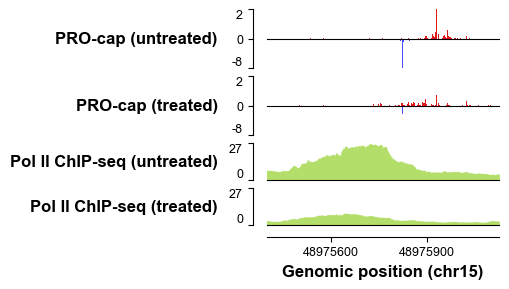

In [138]:
region = "chr15:48975400-48976124"
plot_example(region)

## Call loops

In [41]:
# Call significant loops for individual replicates and merged ones

samples2 = list(conditions)+[rep for k in conditions for rep in hichip_reps[k]]

In [18]:
chrom_sizes = "/fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/HiC-Pro_install/HiC-Pro_3.1.0/annotation/chrom_hg38.sizes"

In [135]:
# Prepare configuration file for each replicate and each condition

template = f"{PROJECT_DIR_s}FitHiChIP/configfile_BiasCorrection_CoverageBias"
with open(template) as f:
	lines = f.readlines()

for sample in samples2:
	outdir2 = f"{outdir}FitHiChIP/loops/{sample}/"
	os.makedirs(outdir2, exist_ok=True)
	outputfile = f"{outdir2}configfile_BiasCorrection_CoverageBias"
	if sample in ["untreated"] or sample in hichip_reps["untreated"]:
		peak_file = peak_files["untreated"]
	else:
		peak_file = peak_files["treated"]
			
	replacements = {"ValidPairs=": f"ValidPairs={outdir}processed_HiChIP/hic_results/data/{sample}/{sample}.allValidPairs",
				    "ChrSizeFile=": f"ChrSizeFile={chrom_sizes}",
					"PeakFile=": f"PeakFile={peak_file}",
				    "OutDir=": f"OutDir={outdir2}",
					"BINSIZE=": "BINSIZE=10000",
				    "OverWrite=": "OverWrite=1"
					}
	new_lines = []
	for line in lines:
	    stripped = line.lstrip()
	    for key, new in replacements.items():
	        if stripped.startswith(key):
	            line = new + "\n"
	    new_lines.append(line)
	
	with open(outputfile, "w") as f:
	    f.writelines(new_lines)

In [40]:
for sample in samples2:
	commands = ["sh", f"{PROJECT_DIR_s}FitHiChIP/FitHiChIP_HiCPro.sh",
				"-C", f"{outdir}FitHiChIP/loops/{sample}/configfile_BiasCorrection_CoverageBias"
			   ]
	print(" ".join(commands))

sh /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/FitHiChIP/FitHiChIP_HiCPro.sh -C /home/yc2553/databases/GEO/GSE179545/FitHiChIP/loops/SRR15050696/configfile_BiasCorrection_CoverageBias
sh /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/FitHiChIP/FitHiChIP_HiCPro.sh -C /home/yc2553/databases/GEO/GSE179545/FitHiChIP/loops/SRR15050698/configfile_BiasCorrection_CoverageBias
sh /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/FitHiChIP/FitHiChIP_HiCPro.sh -C /home/yc2553/databases/GEO/GSE179545/FitHiChIP/loops/untreated/configfile_BiasCorrection_CoverageBias
sh /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/FitHiChIP/FitHiChIP_HiCPro.sh -C /home/yc2553/databases/GEO/GSE179545/FitHiChIP/loops/SRR15050697/configfile_BiasCorrection_CoverageBias
sh /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/FitHiChIP/FitHiChIP_HiCPro.sh -C /home/yc2553/databases/GEO/GSE179545/FitH

In [50]:
# https://ay-lab.github.io/FitHiChIP/html/usage/output.html
# Check No. significant loops after merging filter

results = []
for k in conditions:
	inputfile = f"{outdir}FitHiChIP/loops/{k}/FitHiChIP_Peak2ALL_b10000_L20000_U2000000/P2PBckgr_0/Coverage_Bias/FitHiC_BiasCorr/Merge_Nearby_Interactions/FitHiChIP.interactions_FitHiC_Q0.01_MergeNearContacts.bed"
	results.append([k, len(pd.read_table(inputfile))])
	for rep in hichip_reps[k]:
		inputfile = f"{outdir}FitHiChIP/loops/{rep}/FitHiChIP_Peak2ALL_b10000_L20000_U2000000/P2PBckgr_0/Coverage_Bias/FitHiC_BiasCorr/Merge_Nearby_Interactions/FitHiChIP.interactions_FitHiC_Q0.01_MergeNearContacts.bed"
		results.append([f"{k} (rep{hichip_reps[k].index(rep)+1})", len(pd.read_table(inputfile))])
pd.DataFrame(results, columns=["Sample", "No. significant loops after merging filter"])

,Sample,No. significant loops after merging filter
0,untreated,16970
1,untreated (rep1),5078
2,untreated (rep2),6101
3,treated,3296
4,treated (rep1),791
5,treated (rep2),359


In [133]:
# Reproduce figures in Lee et al. as sanity check

def plot_interactions(region, vmin=2, vmax=10):
	chrom, coords = region.split(":")
	start, end = map(int, coords.split("-"))

	norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
	cmap = plt.cm.Reds
	
	fig, ax = plt.subplots(2, 1, figsize=(9, 4))
	
	for k in conditions:
		row = conditions.index(k)
		
		df = pd.read_table(f"{outdir}FitHiChIP/loops/{k}/FitHiChIP_Peak2ALL_b10000_L20000_U2000000/P2PBckgr_0/Coverage_Bias/FitHiC_BiasCorr/Merge_Nearby_Interactions/FitHiChIP.interactions_FitHiC_Q0.01_MergeNearContacts_IGV.bedpe", header=None)
		df.columns = [
		    "chr1","start1","end1",
		    "chr2","start2","end2",
		    "strand","value",8,9
		]
		
		sub = df[(df.chr1 == chrom) &
			    (((df.start1 >= start) & (df.start1 <= end)) |
			        ((df.start2 >= start) & (df.start2 <= end))
			    )
			].reset_index(drop=True)
	
		vals = sub["value"].clip(lower=vmin, upper=vmax)
	
		for i, drow in sub.iterrows():
		    x1 = drow.start1
		    x2 = drow.start2
		    xm = (x1 + x2) / 2
		    r = (x2 - x1) / 2
		    height = r
		
		    theta = np.linspace(0, np.pi, 200)
		    xs = xm + r * np.cos(theta)
		    ys = height * np.sin(theta)
		
		    ax[row].plot(xs, ys, color=cmap(norm(vals.iloc[i])), linewidth=1)
		
		ax[row].set_xlim(start, end)
		ax[row].set_xticks([start, end])
		if row == 1:
			ax[row].set_xticklabels([start, end], fontsize=sfontsize)
			ax[row].set_xlabel(chrom, fontsize=bfontsize)
		else:
			ax[row].set_xticklabels([])
			ax[row].set_xlabel("")

		ax[row].set_ylim(0, sub["start2"].sub(sub["start1"]).max() * 0.6)
		ax[row].set_ylabel(k.capitalize(), fontsize=bfontsize)
		ax[row].set_yticks([])
		ax[row].spines[["top", "bottom", "left", "right"]].set_visible(False)
		
	sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
	cax = fig.add_axes([0.1, -0.1, 0.1, 0.03])
	cbar = fig.colorbar(sm, cax=cax, orientation='horizontal')
	cbar.set_label('-log$_{10}$(FDR)', fontsize=sfontsize)
	cbar.set_ticks([2, 10])

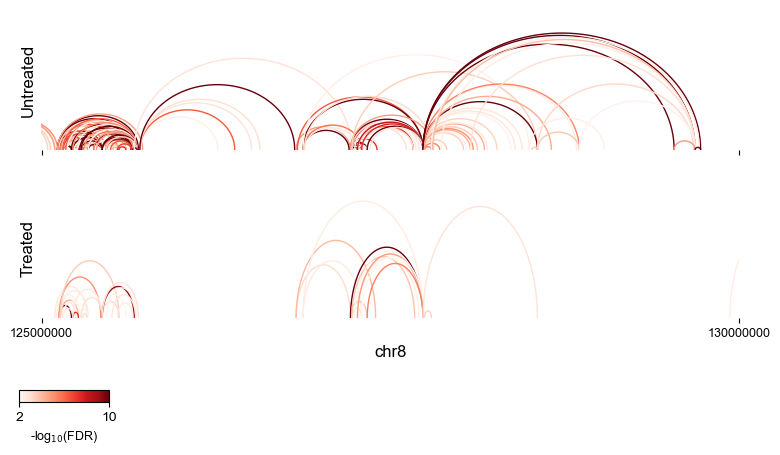

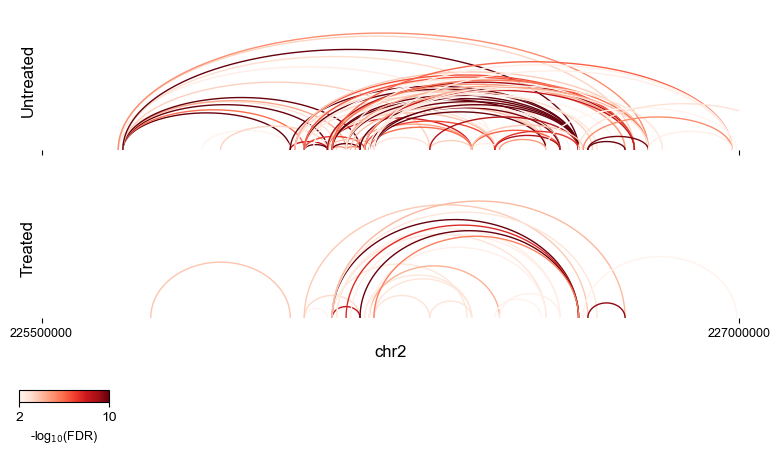

In [134]:
regions = ["chr8:125000000-130000000", "chr2:225500000-227000000"]
for region in regions:
	plot_interactions(region)

## Differential loops

In [12]:
diff_outdir = f"{outdir}FitHiChIP/differential_loops/"

In [25]:
# Rename filenames for differential loop analysis

for k in conditions:
	for rep in hichip_reps[k]:
		inputfile = f"{outdir}FitHiChIP/loops/{rep}/FitHiChIP_Peak2ALL_b10000_L20000_U2000000/P2PBckgr_0/Coverage_Bias/FitHiC_BiasCorr/FitHiChIP.interactions_FitHiC.bed"
		linkname = f"{diff_outdir}{k}_rep{hichip_reps[k].index(rep)+1}.interactions_FitHiC.bed"
		subprocess.run(["ln", "-sf", inputfile, linkname], check=True)

In [19]:
# Note that we'll look into elements with PRO-cap changes, so Pol II ChIP-seq classifications are not necessary

# --FDRThr: FDR significance threshold for FitHiChIP loops. Default = 0.01.
# --BackgroundFDRThr: FDR threshold for FitHiChIP loops which will be considered for defining the background model. Default is 1, means every FitHiChIP contact in the input samples would be considered as background loops of the edgeR model. A value of 0.01 would indicate that the FitHiChIP loops with q-value < 0.01 in at least one sample would be used as the background. If the input samples have very low contact counts for most of the input samples and loops, user may alter this parameter (like 0.1) to include only the significant (or moderately significant) FitHiChIP loops (in at least one input sample) to define the background model.
# --FoldChangeThr: EdgeR fold change threshold. Default = 2 means log2(2) = 1 is employed as the fold change threshold on the EdgeR output.
# --DiffFDRThr: FDR threshold for EdgeR. Default is 0.05, means that loops with FDR < 0.05, and fold change >= log2(FoldChangeThr) would be considered as differential.

commands = ["Rscript", f"{PROJECT_DIR_s}FitHiChIP/Imp_Scripts/DiffAnalysisHiChIP.r",
			# Comma or colon separated list of loops with FitHiChIP significance (FDR) values, for all categories and all replicates; all the samples of category 1 should be specified first, followed by the samples in category 2.
			"--AllLoopList", ",".join([f"{diff_outdir}{k}_{rep}.interactions_FitHiC.bed" for k in conditions for rep in ["rep1", "rep2"]]),
			# Either two files, one for each category, are to be given. Or, provide ChIP seq alignment files one for each sample.
			# "--ChIPAlignFileList", ",".join([f"{diff_outdir}{k}_{rep}.bam" for k in conditions for rep in ["rep1", "rep2"]]),
			"--OutDir", diff_outdir,
			# Comma or colon separated list of strings, representing labels of two categories.
			"--CategoryList", "untreated,treated",
			# Comma or colon separated list representing the count of samples (replicates) belonging to individual categories.
			"--ReplicaCount", "2,2",
			# Comma or colon separated list of the label of replicates for the first category.
			"--ReplicaLabels1", "rep1,rep2",
			# Comma or colon separated list of the label of replicates for the second category.
			"--ReplicaLabels2", "rep1,rep2",
			"--ChrSizeFile", chrom_sizes
		   ]
print(" ".join(commands))

Rscript /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/FitHiChIP/Imp_Scripts/DiffAnalysisHiChIP.r --AllLoopList /home/yc2553/databases/GEO/GSE179545/FitHiChIP/differential_loops/untreated_rep1.interactions_FitHiC.bed,/home/yc2553/databases/GEO/GSE179545/FitHiChIP/differential_loops/untreated_rep2.interactions_FitHiC.bed,/home/yc2553/databases/GEO/GSE179545/FitHiChIP/differential_loops/treated_rep1.interactions_FitHiC.bed,/home/yc2553/databases/GEO/GSE179545/FitHiChIP/differential_loops/treated_rep2.interactions_FitHiC.bed --OutDir /home/yc2553/databases/GEO/GSE179545/FitHiChIP/differential_loops/ --CategoryList untreated,treated --ReplicaCount 2,2 --ReplicaLabels1 rep1,rep2 --ReplicaLabels2 rep1,rep2 --ChrSizeFile /fs/cbsuhy02/storage/yc2553/yc2553/projects/TRE_directionality/softwares/HiC-Pro_install/HiC-Pro_3.1.0/annotation/chrom_hg38.sizes


In [38]:
df = pd.read_table(f"{diff_outdir}EdgeR_Loops_ALL/Loops_EdgeR_Default_SIG.bed")
df.head(2)

,chr1,start1,end1,chr2,start2,end2,untreated_rep1_RawCC,untreated_rep1_QVal,untreated_rep2_RawCC,untreated_rep2_QVal,treated_rep1_RawCC,treated_rep1_QVal,treated_rep2_RawCC,treated_rep2_QVal,logFC,logCPM,PValue,FDR,untreated_SigRepl,treated_SigRepl
0,chr1,920000,930000,chr1,940000,950000,0,1.0,0,1.0,14,0.637810,14,0.778885,6.832409,1.019909,2.527219e-08,0.000016,0,0
1,chr1,1080000,1090000,chr1,1100000,1110000,0,1.0,0,1.0,5,0.897057,8,0.889355,5.740560,0.241916,3.114045e-04,0.042219,0,0


In [42]:
# Sanity check

len(df), np.min(df["logFC"].abs()), np.max(df["FDR"])

(29580, 1.0150880518295, 0.0499941115693926)

In [31]:
df.to_csv(f"{diff_outdir}EdgeR_Loops_ALL/Loops_EdgeR_Default_SIG_noheader.bed", header=False, index=False, sep="\t")

In [44]:
# In their original pipeline, they overlap differential loops (EdgeR) with significant loops identified from individual replicate; but we note that merged replicates at sample level have better power to identify significant loops compared to individual replicates

b1 = pybedtools.BedTool(f"{diff_outdir}EdgeR_Loops_ALL/Loops_EdgeR_Default_SIG_noheader.bed")
for k in conditions:
	b2 = pybedtools.BedTool(f"{outdir}FitHiChIP/loops/{k}/FitHiChIP_Peak2ALL_b10000_L20000_U2000000/P2PBckgr_0/Coverage_Bias/FitHiC_BiasCorr/Merge_Nearby_Interactions/FitHiChIP.interactions_FitHiC_Q0.01_MergeNearContacts_IGV.bedpe")
	# No. differential loops overlapping with significant loops a given condition
	print(k, len(b1.intersect(b2, u=True)))

untreated 6645
treated 1961
